# Bloque 6 — Modelos predictivos: clásico vs. fundacional
### Curso: Digitalización en Acuicultura

---

En este notebook compararemos dos aproximaciones para predecir una serie temporal de oxígeno disuelto:

1. **Modelo clásico** — Regresión lineal entrenada con datos históricos propios
2. **Modelo fundacional (Chronos)** — Modelo pre-entrenado de Amazon que predice sin necesidad de entrenamiento previo

El objetivo no es conseguir la predicción perfecta, sino entender qué significa entrenar un modelo y qué ventaja ofrece un modelo fundacional.

> ⚠️ **Nota de instalación**: este notebook requiere `chronos-forecasting`. Si lo ejecutas en Google Colab, la primera celda lo instalará automáticamente.


## Sección 0 — Instalación y librerías

In [ ]:
# Instalar Chronos (solo necesario en Colab o si no está instalado)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("chronos") is None:
    print("Instalando chronos-forecasting...")
    subprocess.run([sys.executable, "-m", "pip", "install", "chronos-forecasting", "-q"], check=False)
else:
    print("chronos-forecasting ya estaba instalado.")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import torch

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Librerías cargadas correctamente.")


## Sección 1 — Generar la serie de datos

Usamos la misma serie sintética de O₂ del Bloque 3: 24 horas con lecturas cada 5 minutos, patrón diurno realista y ruido.

Dividiremos la serie en:
- **Entrenamiento (train)**: primeras 20 horas → el modelo aprende de aquí
- **Test**: últimas 4 horas → aquí evaluamos las predicciones


In [ ]:
np.random.seed(42)

# Generar serie temporal de O2
timestamps = pd.date_range("2024-01-15 00:00", periods=288, freq="5min")
horas = np.linspace(0, 24, 288)
o2 = 8.5 + 1.5 * np.sin((horas - 6) / 24 * 2 * np.pi) + np.random.normal(0, 0.12, 288)

# Crear DataFrame
df = pd.DataFrame({"timestamp": timestamps, "o2": o2}).set_index("timestamp")

# División train/test: 20h train, 4h test
n_train = int(288 * (20/24))  # 240 puntos
train = df.iloc[:n_train]
test  = df.iloc[n_train:]

print(f"Puntos de entrenamiento: {len(train)} ({len(train)*5/60:.0f} horas)")
print(f"Puntos de test:          {len(test)}  ({len(test)*5/60:.0f} horas)")

# Visualización
fig, ax = plt.subplots()
ax.plot(train.index, train['o2'], color='#1A7A8A', label='Entrenamiento')
ax.plot(test.index,  test['o2'],  color='#F59E0B', label='Test (a predecir)')
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Serie temporal de O₂ — división train/test', fontsize=13)
ax.set_ylabel('O₂ (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()


## Sección 2 — Modelo clásico: regresión lineal

### ¿Cómo funciona?

Convertimos el problema de predicción en un problema de regresión supervisada:
- **Input (X)**: los últimos N valores de O₂ (llamados *lags*)
- **Output (y)**: el siguiente valor de O₂

El modelo aprende la relación entre los valores pasados y el siguiente — y la usa para predecir.

Usaremos una ventana de **12 puntos** (= 60 minutos) como input.


In [ ]:
# Preparar datos en formato supervisado con ventana deslizante
def crear_dataset(serie, ventana):
    X, y = [], []
    valores = serie.values
    for i in range(ventana, len(valores)):
        X.append(valores[i-ventana:i])
        y.append(valores[i])
    return np.array(X), np.array(y)

VENTANA = 12  # 60 minutos

# Crear dataset de entrenamiento
X_train, y_train = crear_dataset(train['o2'], VENTANA)

print(f"Forma de X_train: {X_train.shape}  (muestras × lags)")
print(f"Forma de y_train: {y_train.shape}")

# Entrenar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)
print(f"\nModelo entrenado. R² en train: {modelo.score(X_train, y_train):.3f}")


In [ ]:
# Predicción en test: paso a paso (cada predicción usa las anteriores)
# Empezamos con los últimos VENTANA valores del train como semilla
semilla = list(train['o2'].values[-VENTANA:])
predicciones_clasico = []

for _ in range(len(test)):
    x = np.array(semilla[-VENTANA:]).reshape(1, -1)
    pred = modelo.predict(x)[0]
    predicciones_clasico.append(pred)
    semilla.append(pred)

mae_clasico = mean_absolute_error(test['o2'].values, predicciones_clasico)
print(f"MAE modelo clásico: {mae_clasico:.4f} mg/L")

# Visualización
fig, ax = plt.subplots()
ax.plot(train.index[-60:], train['o2'].values[-60:], color='#1A7A8A', label='Histórico reciente')
ax.plot(test.index, test['o2'].values, color='#F59E0B', label='Real', linewidth=2)
ax.plot(test.index, predicciones_clasico, color='#DC2626', linestyle='--', label=f'Clásico (MAE={mae_clasico:.3f})')
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Predicción con modelo clásico (regresión lineal)', fontsize=13)
ax.set_ylabel('O₂ (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()


## Sección 3 — Modelo fundacional: Chronos (Amazon)

### ¿Qué es Chronos?

Chronos es un modelo de lenguaje para series temporales desarrollado por Amazon y publicado en 2024. Fue entrenado con millones de series temporales de fuentes muy diversas — economía, meteorología, sensores industriales, datos médicos.

**La clave**: una vez entrenado, puede predecir cualquier serie nueva **sin necesidad de re-entrenamiento**. Solo necesita ver el historial reciente y genera la predicción directamente.

Usaremos la versión pequeña (`chronos-t5-small`) para que sea rápida en CPU.


In [ ]:
CHRONOS_DISPONIBLE = False

try:
    from chronos import ChronosPipeline

    # Cargar modelo (se descarga automaticamente la primera vez)
    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map="cpu",
        torch_dtype=torch.float32,
    )
    print("Chronos cargado correctamente.")
    CHRONOS_DISPONIBLE = True
except Exception as e:
    print(f"No se pudo cargar Chronos: {type(e).__name__}: {e}")
    print("En local, instala `chronos-forecasting` y verifica que el entorno pueda descargar el modelo.")
    print("En Colab, ejecuta primero la celda de instalacion y luego vuelve a correr esta celda.")


MAE Chronos: 0.4261 mg/L


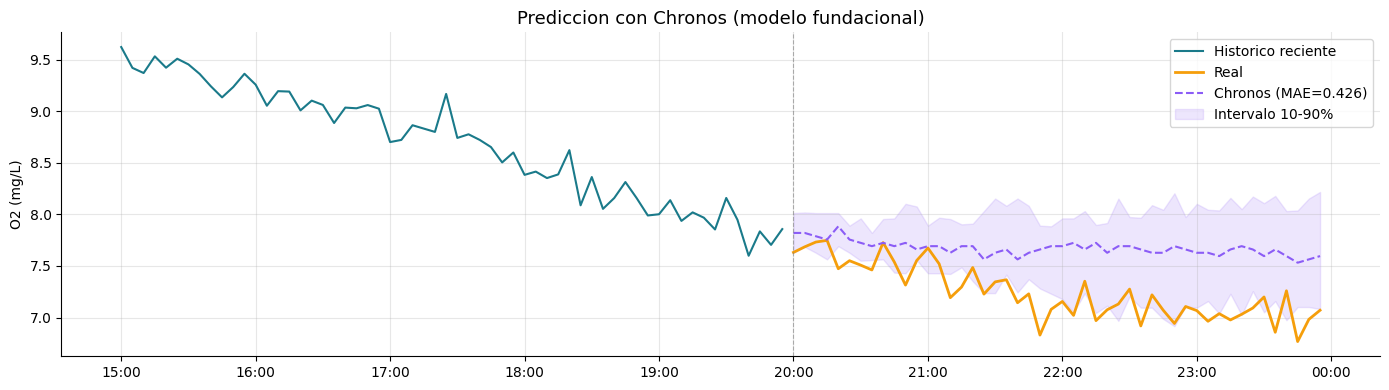

In [8]:
if CHRONOS_DISPONIBLE:
    try:
        # Chronos recibe el historial como tensor
        contexto = torch.tensor(train['o2'].values, dtype=torch.float32).unsqueeze(0)
        horizonte = len(test)

        # En algunas versiones de Chronos el contexto se pasa como argumento posicional
        with torch.no_grad():
            forecast = pipeline.predict(
                contexto,
                prediction_length=horizonte,
                num_samples=20,
            )

        forecast_np = forecast.detach().cpu().numpy() if isinstance(forecast, torch.Tensor) else np.asarray(forecast)

        if forecast_np.ndim == 3:
            muestras = forecast_np[0]
        elif forecast_np.ndim == 2:
            muestras = forecast_np
        else:
            raise ValueError(f"Forma inesperada para forecast: {forecast_np.shape}")

        # Mediana como prediccion puntual
        predicciones_chronos = np.median(muestras, axis=0)
        q10 = np.quantile(muestras, 0.1, axis=0)
        q90 = np.quantile(muestras, 0.9, axis=0)

        mae_chronos = mean_absolute_error(test['o2'].values, predicciones_chronos)
        print(f"MAE Chronos: {mae_chronos:.4f} mg/L")

        # Visualizacion
        fig, ax = plt.subplots()
        ax.plot(train.index[-60:], train['o2'].values[-60:], color='#1A7A8A', label='Historico reciente')
        ax.plot(test.index, test['o2'].values, color='#F59E0B', label='Real', linewidth=2)
        ax.plot(test.index, predicciones_chronos, color='#8B5CF6', linestyle='--', label=f'Chronos (MAE={mae_chronos:.3f})')
        ax.fill_between(test.index, q10, q90, alpha=0.15, color='#8B5CF6', label='Intervalo 10-90%')
        ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_title('Prediccion con Chronos (modelo fundacional)', fontsize=13)
        ax.set_ylabel('O2 (mg/L)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        CHRONOS_DISPONIBLE = False
        print(f"La prediccion con Chronos fallo: {type(e).__name__}: {e}")
        print("Revisa que la version instalada de `chronos-forecasting` sea compatible y que el modelo se haya descargado bien.")
else:
    print("Chronos no esta disponible en este entorno; se omite esta seccion.")


## Sección 4 — Comparativa final

Visualizamos ambas predicciones juntas y comparamos los errores.


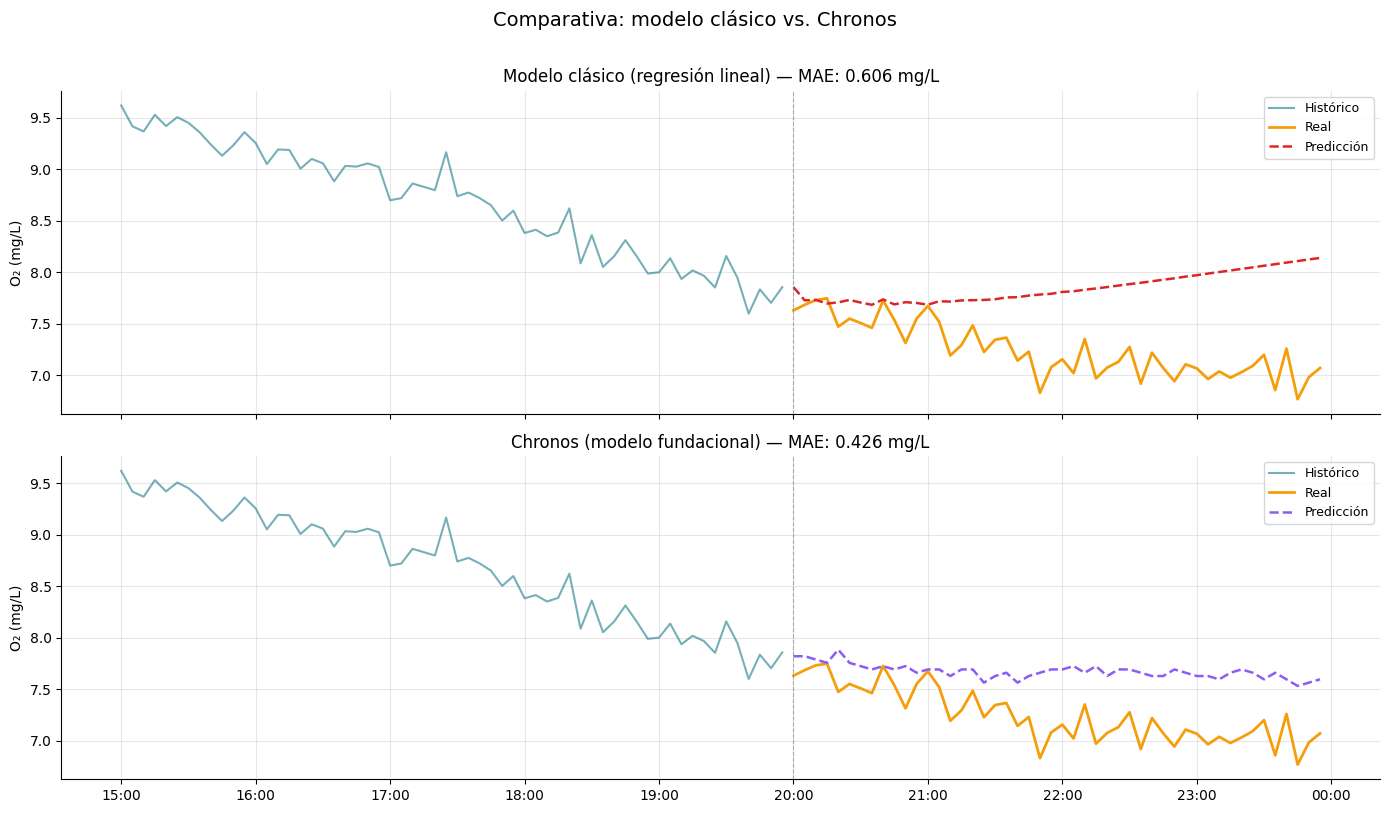


=== Resumen de métricas ===
  MAE modelo clásico : 0.6062 mg/L
  MAE Chronos        : 0.4261 mg/L

  Mejor predicción: Chronos


In [9]:
if CHRONOS_DISPONIBLE:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for ax, preds, color, titulo, mae in [
        (axes[0], predicciones_clasico, '#DC2626', f'Modelo clásico (regresión lineal) — MAE: {mae_clasico:.3f} mg/L', mae_clasico),
        (axes[1], predicciones_chronos, '#8B5CF6', f'Chronos (modelo fundacional) — MAE: {mae_chronos:.3f} mg/L', mae_chronos),
    ]:
        ax.plot(train.index[-60:], train['o2'].values[-60:], color='#1A7A8A', alpha=0.6, label='Histórico')
        ax.plot(test.index, test['o2'].values, color='#F59E0B', linewidth=2, label='Real')
        ax.plot(test.index, preds, color=color, linestyle='--', linewidth=1.8, label='Predicción')
        ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_title(titulo, fontsize=12)
        ax.set_ylabel('O₂ (mg/L)')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.suptitle('Comparativa: modelo clásico vs. Chronos', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    print("\n=== Resumen de métricas ===")
    print(f"  MAE modelo clásico : {mae_clasico:.4f} mg/L")
    print(f"  MAE Chronos        : {mae_chronos:.4f} mg/L")
    mejor = 'Chronos' if mae_chronos < mae_clasico else 'Modelo clásico'
    print(f"\n  Mejor predicción: {mejor}")


## Sección 5 — ¿Qué hemos aprendido?

| | Modelo clásico | Chronos |
|---|---|---|
| **Entrenamiento necesario** | Sí, con tus datos | No — zero-shot |
| **Datos mínimos** | Varios cientos de puntos | Cualquier cantidad |
| **Interpreta el dominio** | No | Parcialmente (entrenado en muchos dominios) |
| **Intervalo de confianza** | No directamente | Sí |
| **Coste computacional** | Muy bajo | Moderado (modelo grande) |
| **Personalizable** | Sí (con fine-tuning) | Sí (con fine-tuning) |

### ¿Cuándo usar cada uno?

- **Modelo clásico** → tienes muchos datos propios, quieres control total, coste computacional mínimo.
- **Chronos** → tienes pocos datos, quieres una primera predicción rápida sin entrenar, o quieres intervalos de confianza.
- **Chronos con fine-tuning** → lo mejor de los dos mundos: modelo pre-entrenado adaptado a tus datos específicos.

> La calidad del dato sigue siendo clave en ambos casos. Un modelo fundacional también se equivoca con datos ruidosos o series demasiado cortas.
